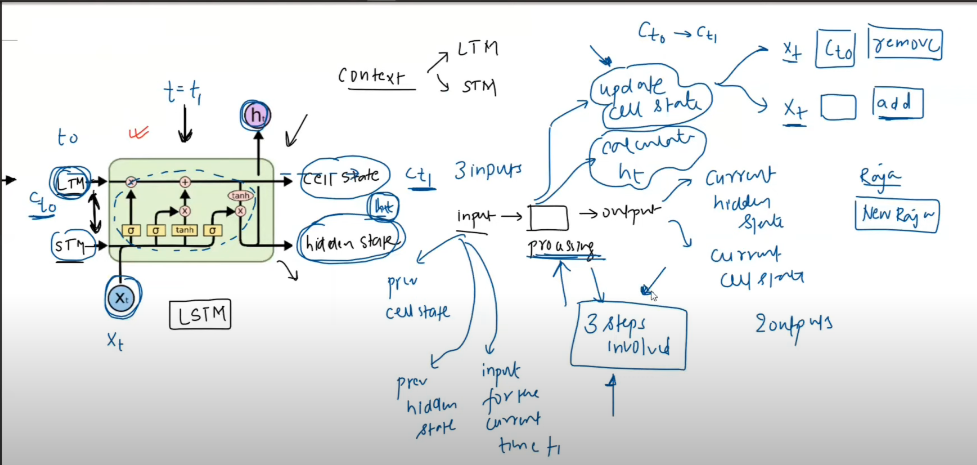

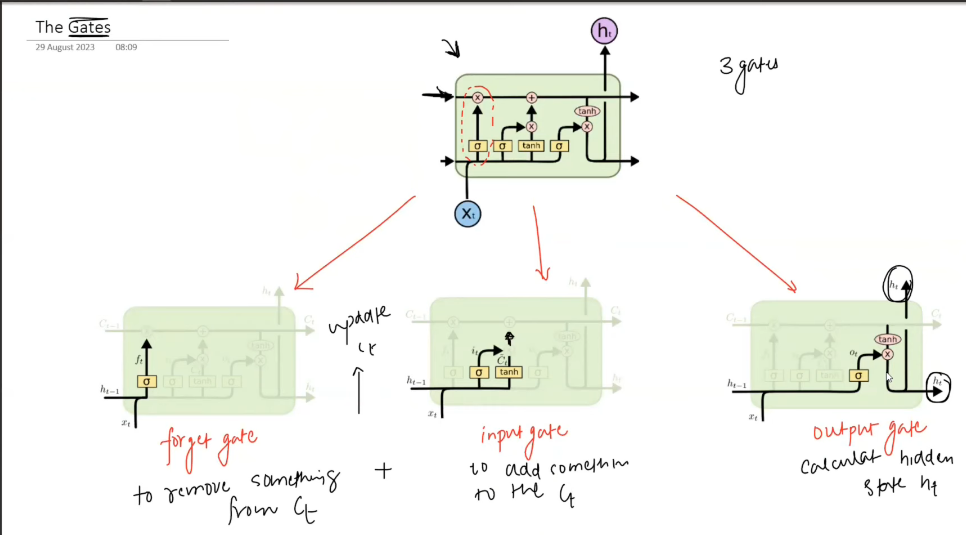

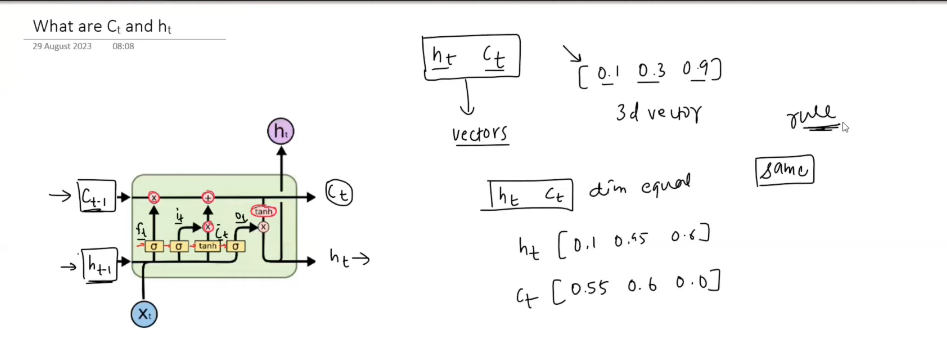

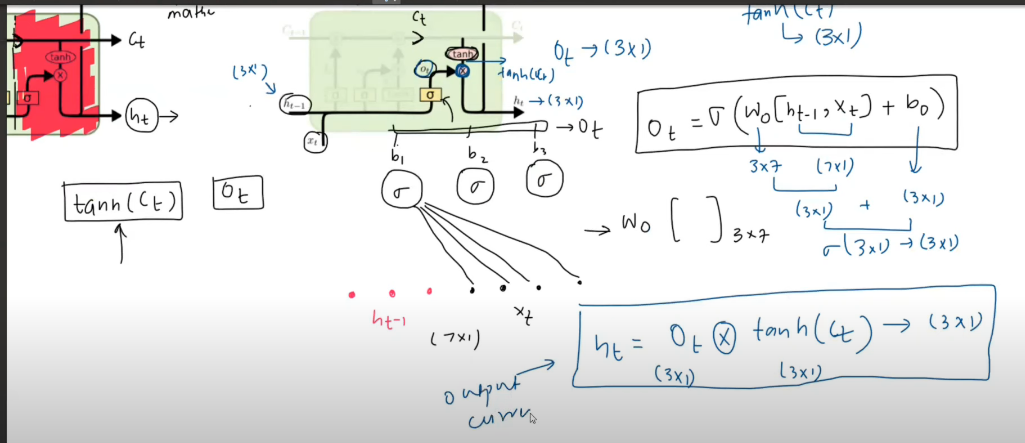


---

# 🧠 **LSTM Architecture Deep Dive: From Diagrams to Logic**

This guide walks through the **structure and function of an LSTM cell**, using insights from your provided video transcript and hand-drawn diagrams (which appear to be lecture-style visuals). We'll break it down step by step, matching each component with its role in information processing.

---

## 🔍 Overview: What Is an LSTM?

A **Long Short-Term Memory (LSTM)** network is a type of **Recurrent Neural Network (RNN)** designed to model sequences while retaining long-term dependencies.

It overcomes the limitations of vanilla RNNs by introducing:
- A **cell state (Ct)**: The "memory highway" that carries information across time steps.
- A **hidden state (Ht)**: The output at each step, used for predictions and internal updates.
- **Gates**: Controlled switches that regulate what gets remembered, forgotten, or output.

> 💡 Think of it as a **smart memory system** where decisions about remembering or forgetting are made dynamically based on input.

---

## 📐 Core Components of the LSTM Cell

Let’s examine the diagram:

```
[Input] Xt
       ↓
     [LSTM Cell]
       ↑         ↑
   Ct-1 ←──────→ Ht-1
       ↑         ↑
    [Cell State]  [Hidden State]
       ↓         ↓
      Ct        Ht → Output
```

### ✅ Inputs:
1. `Xt`: Current input (e.g., word embedding).
2. `Ct-1`: Previous cell state (long-term memory).
3. `Ht-1`: Previous hidden state (short-term memory).

### ✅ Outputs:
1. `Ct`: Updated cell state → passed to next time step.
2. `Ht`: Updated hidden state → used as output and next-step context.

---

## 🎯 Key Concepts Visualized

### 1. **Cell State vs Hidden State**

From your third image:

```
ht = [0.1, 0.45, 0.6]
ct = [0.55, 0.6, 0.7]
```

Both are **vectors** of equal dimension (e.g., 3D), but serve different roles:
- **Ct (Cell State)**: Long-term memory; flows horizontally through time.
- **Ht (Hidden State)**: Short-term memory; outputs current prediction and feeds into gates.

> 🔁 They interact via **gates** and **activation functions**.

---

## ⚙️ The Three Gates Explained

As shown in the second diagram, the LSTM has **three main gates**:

| Gate | Purpose | Activation |
|------|--------|-----------|
| **Forget Gate (Ft)** | Decide what to **forget** from Ct-1 | Sigmoid (σ) |
| **Input Gate (It)** | Decide what **new info** to add | Sigmoid (σ) |
| **Output Gate (Ot)** | Decide what to **output** as Ht | Sigmoid (σ) |

Each gate takes `[Ht-1, Xt]` as input and applies a **fully connected layer + activation**.

---

### 🔹 1. Forget Gate (Ft)

**Purpose:** Remove irrelevant parts of the old cell state.

```python
Ft = σ(Wf · [Ht-1, Xt] + bf)
```

- `Wf`: Weight matrix for forget gate.
- `bf`: Bias term.
- `σ`: Sigmoid → outputs ∈ [0, 1].

#### 🔧 Operation:
```
Ct_new_part = Ft ⊙ Ct-1   (element-wise multiplication)
```

> - If `Ft ≈ 0`: forget this part.
> - If `Ft ≈ 1`: keep it.

✅ This allows the network to **prune outdated information**.

---

### 🔹 2. Input Gate & Candidate Cell State

Two sub-components work together:

#### a) **Candidate Cell State (C̃t)**

Generates potential new values to add to the cell state.

```python
C̃t = tanh(Wc · [Ht-1, Xt] + bc)
```

- Uses **tanh** → outputs ∈ [-1, 1].
- Represents **raw candidate values**.

#### b) **Input Gate (It)**

Filters which parts of C̃t are important.

```python
It = σ(Wi · [Ht-1, Xt] + bi)
```

Then:
```
New_info = It ⊙ C̃t
```

> Only the **important parts** of the new data get added.

---

### 🔹 3. Update Cell State (Ct)

Now combine the **retained old info** and **filtered new info**:

```python
Ct = (Ft ⊙ Ct-1) + (It ⊙ C̃t)
```

This is the **core update rule**:
- **Addition** allows accumulation of relevant information.
- **Multiplication** enables selective filtering.

> 🌟 Example: If `Ft=1`, `It=0`, then `Ct = Ct-1` → memory preserved exactly!

---

### 🔹 4. Output Gate (Ot)

Determines the **hidden state (Ht)**.

#### Step 1: Apply tanh to current cell state
```
tanh(Ct)
```
→ Scales values between -1 and 1.

#### Step 2: Compute Output Gate
```python
Ot = σ(Wo · [Ht-1, Xt] + bo)
```

#### Step 3: Multiply to get Ht
```
Ht = Ot ⊙ tanh(Ct)
```

> This ensures only **relevant aspects** of the cell state are exposed.

---

## 🧮 Mathematical Summary

Let’s formalize everything:

| Component | Formula |
|---------|--------|
| **Forget Gate** | `Ft = σ(Wf·[Ht-1,Xt] + bf)` |
| **Input Gate** | `It = σ(Wi·[Ht-1,Xt] + bi)` |
| **Candidate Cell** | `C̃t = tanh(Wc·[Ht-1,Xt] + bc)` |
| **Update Cell** | `Ct = Ft⊙Ct-1 + It⊙C̃t` |
| **Output Gate** | `Ot = σ(Wo·[Ht-1,Xt] + bo)` |
| **Hidden State** | `Ht = Ot ⊙ tanh(Ct)` |

> All weights (`Wf`, `Wi`, etc.) and biases (`bf`, `bi`, etc.) are learned during training.

---

## 🖼️ Visual Interpretation of Diagrams

### Image 1: Full LSTM Cell Flow

- Shows **inputs**: `Xt`, `Ct-1`, `Ht-1`.
- Highlights **three gates** inside the green box.
- Arrows show:
  - `Ct` flowing left-to-right (memory highway).
  - `Ht` being output.
  - Red circles: point-wise operations (`⊙`).
  - Blue boxes: neural layers (yellow units in original video).

> ✔️ Emphasizes that **only Ct passes directly** through time; others are updated.

---

### Image 2: The Three Gates Split

Shows how each gate operates independently:

1. **Forget Gate**: Removes from `Ct-1`.
2. **Input Gate**: Adds to `Ct`.
3. **Output Gate**: Computes `Ht`.

> This modular view helps understand **how each gate contributes**.

---

### Image 3: Vector Dimensions

Illustrates:
- `ht` and `ct` are **vectors** of same size (e.g., 3D).
- Example: `ht = [0.1, 0.45, 0.6]`, `ct = [0.55, 0.6, 0.7]`.

> Important: **All gates and states have consistent dimensions**.

---

### Image 4: Output Gate Math

Breaks down:
```
Ot = σ(Wo·[Ht-1,Xt] + bo)
```
With:
- `[Ht-1,Xt]`: Concatenated input (e.g., 7×1).
- `Wo`: Weight matrix (e.g., 3×7).
- Result: `Ot` is 3×1 vector.

Then:
```
Ht = Ot ⊙ tanh(Ct)
```
→ Element-wise multiplication.

> ✅ Dimensionality check: both vectors must be same shape.

---

## 🔄 Animation Insight: How It Works Over Time

The video likely shows an animation where:
1. At each time step, the LSTM receives a new input (e.g., a word).
2. The gates adjust dynamically:
   - In “I am happy”, the model might **remember** “happy” for later sentiment analysis.
   - But **forget** earlier words if they’re no longer relevant.
3. The **cell state (Ct)** evolves gradually, preserving key context.

> This is why LSTMs excel in tasks like **machine translation**, **speech recognition**, and **text generation**.

---

## 🚀 Why LSTMs Are Powerful

| Problem | Solution |
|-------|----------|
| Vanishing gradients | Gradient can flow through additive cell state |
| Long-range dependence | Cell state preserves info over many steps |
| Irrelevant inputs | Gates filter out noise |
| Context retention | Can remember useful facts for hundreds of steps |

---

## 📚 Final Takeaways

| Concept | Explanation |
|-------|-------------|
| **Cell State (Ct)** | Long-term memory; updated via forget/input gates |
| **Hidden State (Ht)** | Short-term memory; output of the cell |
| **Forget Gate** | Controls what to discard from previous memory |
| **Input Gate** | Decides what new info to store |
| **Output Gate** | Determines final output based on current memory |
| **Tanh & Sigmoid** | Enable bounded, interpretable values |
| **Element-wise Ops** | Allow fine-grained control over each memory element |

---

## ✅ Practical Tip: Understanding LSTM Output

In most frameworks (like PyTorch or TensorFlow):
```python
lstm_cell = LSTMCell(input_size=10, hidden_size=5)
output, (hidden_state, cell_state) = lstm_cell(input, (prev_h, prev_c))
```

Here:
- `output` = `Ht`
- `hidden_state` = `Ht`
- `cell_state` = `Ct`

> You can access both `Ht` and `Ct` for downstream tasks.

---

## 🧩 Bonus: Real-World Analogy

Imagine an **office worker managing a notebook**:
- **Cell State (Ct)**: The notebook itself – contains notes, ideas, plans.
- **Hidden State (Ht)**: What they say aloud – summary of current thoughts.
- **Forget Gate**: Erasing outdated notes.
- **Input Gate**: Adding new important details.
- **Output Gate**: Deciding what to tell their boss.

They don’t rewrite the whole notebook every day — just update it selectively.

---




---

# 🧠 LSTM Architecture: Q&A (Frequently Asked Questions)

---

### **Q1: What are the two main states in an LSTM cell, and what do they represent?**

**A:**  
The two main states are:
- **Cell State (Ct)**: Acts as **long-term memory**. It carries information across time steps and can retain or forget data selectively.
- **Hidden State (Ht)**: Acts as **short-term memory**. It is the output of the cell at each time step and is used for predictions and internal computations.

> 🔗 They work together: `Ct` stores long-term context; `Ht` delivers a filtered version of that context as output.

---

### **Q2: What three inputs does an LSTM cell receive at time step *t*?**

**A:**  
At each time step *t*, the LSTM receives:
1. **Xt** – the current input (e.g., a word embedding).
2. **Ht-1** – the previous hidden state.
3. **Ct-1** – the previous cell state.

These inputs are used to compute the new states `Ct` and `Ht`.

---

### **Q3: What are the outputs of an LSTM cell at time step *t*?**

**A:**  
The LSTM produces two outputs:
1. **Ct** – updated cell state (passed to the next time step).
2. **Ht** – updated hidden state (used as output and passed forward).

> ✅ Both `Ct` and `Ht` become inputs for the next time step.

---

### **Q4: Why do LSTMs use gates? What problem do they solve?**

**A:**  
Gates control the **flow of information** within the LSTM. They allow the network to:
- Decide what to **remember or forget**,
- Filter **new information** to add,
- Control what gets **output**.

This gating mechanism helps LSTMs:
- **Mitigate the vanishing gradient problem**,
- **Retain long-term dependencies** over sequences (unlike simple RNNs).

Without gates, RNNs struggle to learn patterns over long sequences.

---

### **Q5: Name the three gates in an LSTM and briefly describe their purpose.**

**A:**  
| Gate | Purpose |
|------|--------|
| **Forget Gate (Ft)** | Decides which parts of the **previous cell state (Ct-1)** should be discarded. |
| **Input Gate (It)** | Determines which parts of **new candidate information (C̃t)** should be added to the cell state. |
| **Output Gate (Ot)** | Controls which parts of the **current cell state (after tanh)** are used to produce the **hidden state (Ht)**. |

Each gate uses a **sigmoid activation** to produce values between 0 and 1, acting as a filter.

---

### **Q6: How is the Forget Gate computed?**

**A:**  
The Forget Gate is calculated as:

```
Ft = σ(Wf · [Ht-1, Xt] + bf)
```

Where:
- `[Ht-1, Xt]` = concatenation of previous hidden state and current input,
- `Wf` = weight matrix for the forget gate,
- `bf` = bias term,
- `σ` = sigmoid activation function.

Then:
```
Retained_memory = Ft ⊙ Ct-1   (element-wise multiplication)
```

> If `Ft ≈ 0` → forget; if `Ft ≈ 1` → keep.

---

### **Q7: What is the Candidate Cell State (C̃t), and how is it generated?**

**A:**  
The **Candidate Cell State (C̃t)** is a **proposed update** to the cell state — potential new values to be added.

It is computed using a **tanh-activated** neural network layer:

```
C̃t = tanh(Wc · [Ht-1, Xt] + bc)
```

- Output range: [-1, 1]
- Represents **new information** that might be useful.

But only parts of it are actually added, controlled by the **Input Gate**.

---

### **Q8: How does the Input Gate work with the Candidate Cell State?**

**A:**  
The Input Gate decides **which parts of C̃t are important enough to add** to the cell state.

Steps:
1. Compute Input Gate:
   ```
   It = σ(Wi · [Ht-1, Xt] + bi)
   ```
2. Multiply it element-wise with the candidate:
   ```
   New_info = It ⊙ C̃t
   ```

> Only components where `It ≈ 1` will pass through.

---

### **Q9: How is the current cell state (Ct) updated?**

**A:**  
The new cell state is formed by combining:
- The **filtered old memory** (`Ft ⊙ Ct-1`)
- The **filtered new information** (`It ⊙ C̃t`)

Formula:
```
Ct = (Ft ⊙ Ct-1) + (It ⊙ C̃t)
```

This **additive update** is key — it allows gradients to flow easily during backpropagation, solving the vanishing gradient issue.

---

### **Q10: How is the hidden state (Ht) produced?**

**A:**  
The hidden state is computed in three steps:

1. Apply **tanh** to the current cell state:
   ```
   tanh(Ct)
   ```
   → Scales values between -1 and 1.

2. Compute the **Output Gate (Ot)**:
   ```
   Ot = σ(Wo · [Ht-1, Xt] + bo)
   ```

3. Element-wise multiply:
   ```
   Ht = Ot ⊙ tanh(Ct)
   ```

> This means only **relevant parts** of the cell state are exposed as output.

---

### **Q11: Why is tanh used in the cell state and output gate?**

**A:**  
- **tanh on C̃t and Ct**: Ensures values stay bounded between -1 and 1, preventing explosion and helping stable training.
- Using `tanh(Ct)` before output ensures the **hidden state remains normalized**, even if the cell state grows large.

Without this, outputs could become unstable or saturate.

---

### **Q12: Why is sigmoid used in the gates?**

**A:**  
Sigmoid outputs values between **0 and 1**, making it perfect for **filtering** via element-wise multiplication.

- A value close to **0** means "block this information".
- A value close to **1** means "let it pass".

This makes the gates act like **soft switches** — learnable, differentiable, and interpretable.

---

### **Q13: What do the red circles in the diagrams represent?**

**A:**  
The **red circles** represent **element-wise operations**:
- **⊙** = element-wise (point-wise) multiplication
- **⊕** = element-wise addition

These are **not matrix operations** — they apply operation-by-operation across vector elements.

Example:
```
[0.8, 0.2] ⊙ [5, -3] = [4.0, -0.6]
```

Used heavily in gate logic.

---

### **Q14: Are all vectors in the LSTM the same size?**

**A:**  
Yes — typically:
- `Ht`, `Ct`, `Ft`, `It`, `Ot`, `C̃t` all have the **same dimension** (e.g., 128, 256, etc.), known as the **hidden size**.
- `Xt` can have a different size (input dimension), but after concatenation with `Ht-1`, it's projected via weights to match.

This consistency allows element-wise operations between gates and states.

---

### **Q15: How does the LSTM prevent the vanishing gradient problem?**

**A:**  
Through the **additive update of the cell state**:

```
Ct = (Ft ⊙ Ct-1) + (It ⊙ C̃t)
```

Unlike RNNs, where the hidden state is fully replaced (leading to multiplicative chains), the **cell state can pass unchanged** when `Ft ≈ 1` and `It ≈ 0`.

This creates a **"highway" for gradients** — enabling information and gradients to flow across many time steps without vanishing.

---

### **Q16: Can you explain the flow of information in one time step?**

**A:**  
Sure! Here’s the full forward pass at time *t*:

1. Receive inputs: `Xt`, `Ht-1`, `Ct-1`
2. Compute:
   - `Ft = σ(Wf·[Ht-1,Xt] + bf)` → decide what to forget
   - `It = σ(Wi·[Ht-1,Xt] + bi)` → decide what to add
   - `C̃t = tanh(Wc·[Ht-1,Xt] + bc)` → generate new candidates
   - `Ct = Ft⊙Ct-1 + It⊙C̃t` → update cell state
   - `Ot = σ(Wo·[Ht-1,Xt] + bo)` → decide what to output
   - `Ht = Ot ⊙ tanh(Ct)` → compute final output
3. Output: `Ht` and `Ct` → passed to next step

🔁 Repeat for next time step.

---

### **Q17: What is the role of the yellow boxes in the diagrams?**

**A:**  
The **yellow boxes** represent **fully connected neural network layers** (also called dense or linear layers).

Each gate (forget, input, output) and the candidate cell state has its own:
- Weight matrix (`Wf`, `Wi`, etc.)
- Bias vector (`bf`, `bi`, etc.)

These parameters are **learned during training** to optimize the network’s ability to remember, forget, and predict.

---

### **Q18: What happens if the Forget Gate outputs all 1s?**

**A:**  
If `Ft = [1, 1, ..., 1]`, then:
```
Ft ⊙ Ct-1 = Ct-1
```
→ The entire previous cell state is **fully preserved**.

This means the LSTM decides **nothing needs to be forgotten** — useful for maintaining long-term context (e.g., subject of a sentence).

---

### **Q19: What happens if the Input Gate outputs all 0s?**

**A:**  
If `It = [0, 0, ..., 0]`, then:
```
It ⊙ C̃t = 0
```
→ No new information is added.

So:
```
Ct = Ft ⊙ Ct-1
```
→ The cell state only retains (possibly filtered) old info.

Useful when current input is irrelevant (e.g., filler words like “the”, “a”).

---

### **Q20: Why is the cell state called a "memory highway"?**

**A:**  
Because the **cell state flows horizontally across time steps**, largely unchanged unless gates intervene.

It’s like a **conveyor belt** carrying information:
- Gates act as **on/off ramps** (adding or removing info),
- But the belt itself is continuous.

This design enables **long-range information flow**, which is why LSTMs were so successful before Transformers.

---

## 🎓 Summary Table: Key LSTM Components

| Component | Symbol | Activation | Purpose |
|--------|--------|-----------|--------|
| Forget Gate | Ft | Sigmoid (σ) | Decide what to forget from Ct-1 |
| Input Gate | It | Sigmoid (σ) | Decide what new info to add |
| Candidate Cell | C̃t | Tanh | Generate new memory proposals |
| Cell State | Ct | None (but uses tanh) | Store long-term memory |
| Output Gate | Ot | Sigmoid (σ) | Decide what to output |
| Hidden State | Ht | None | Final output and context |

---

